In [1]:
import sys
from datetime import datetime, timedelta

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
import numpy.ma as ma
import matplotlib.ticker as ticker
from scipy import stats
import os 
os.listdir("/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work")

import matplotlib.colors as mcolors # Import les palettes de couleurs
import cartopy.crs as ccrs # Permet d'utiliser des projections de cartes
import cartopy.feature as cfeature # Permet d'ajouter d'autres éléments à la carte
import matplotlib.patches as patches # Permet de tracer des rectangles dans mon cas


In [2]:
k = 15 # Pixels à retirer aux bords du domaine (éviter effet de bord)

In [3]:
# MAR topography (pas la même correction que Xavier applique, car non nécessaire ici)

GridPath='/home/amoryc/'## Plot de la Temperature de surface de la grille correspondant au glacier Mera
Domain_grM='NST.2000.01.01.00.GRq.nc'

ds_grM= xr.open_dataset(GridPath+Domain_grM) # ds pour DataSet
#print(ds_grM)

ds_lon = ds_grM.LON[k:-k, k:-k] # Longitude
ds_lat = ds_grM.LAT[k:-k, k:-k] # Latitude
ds_SH  = ds_grM.SH[k:-k, k:-k] # Topographie en m
ds_ICE = ds_grM.ICE[k:-k, k:-k] # Pourcentage de glace par maille

# Coordonnées exactes du Peak Mera
merap_lat = 27.70984
merap_lon = 86.868662

# Coordonnées Everest
everest_lat = 27.9879017
everest_lon = 86.9253141

# Carte du pourcentage de glace par point de grille

In [4]:
ice_level = 30 # Seuil à partir duquel on considère qu'on observe de la glace

clevs = np.arange(0, 110, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm_blue = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 

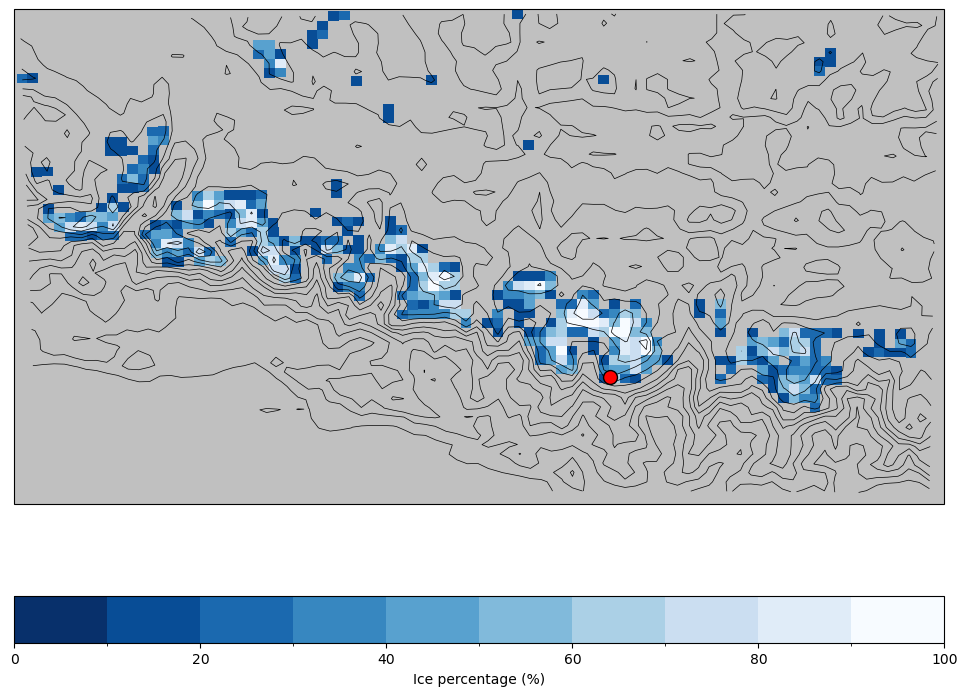

In [5]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

ax.set_facecolor('silver') # Fond de l'image en gris 
ICE_mask = np.ma.masked_where(ds_ICE ==0, ds_ICE) # Créer un mask sur les valeurs de % de glace nul

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Percentage of ice ####
im = ax.pcolormesh(ds_lon, ds_lat, ICE_mask,
                   cmap=cmap, norm=norm_blue, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")

plt.colorbar(im, orientation="horizontal", pad=0.1, label="Ice percentage (%)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

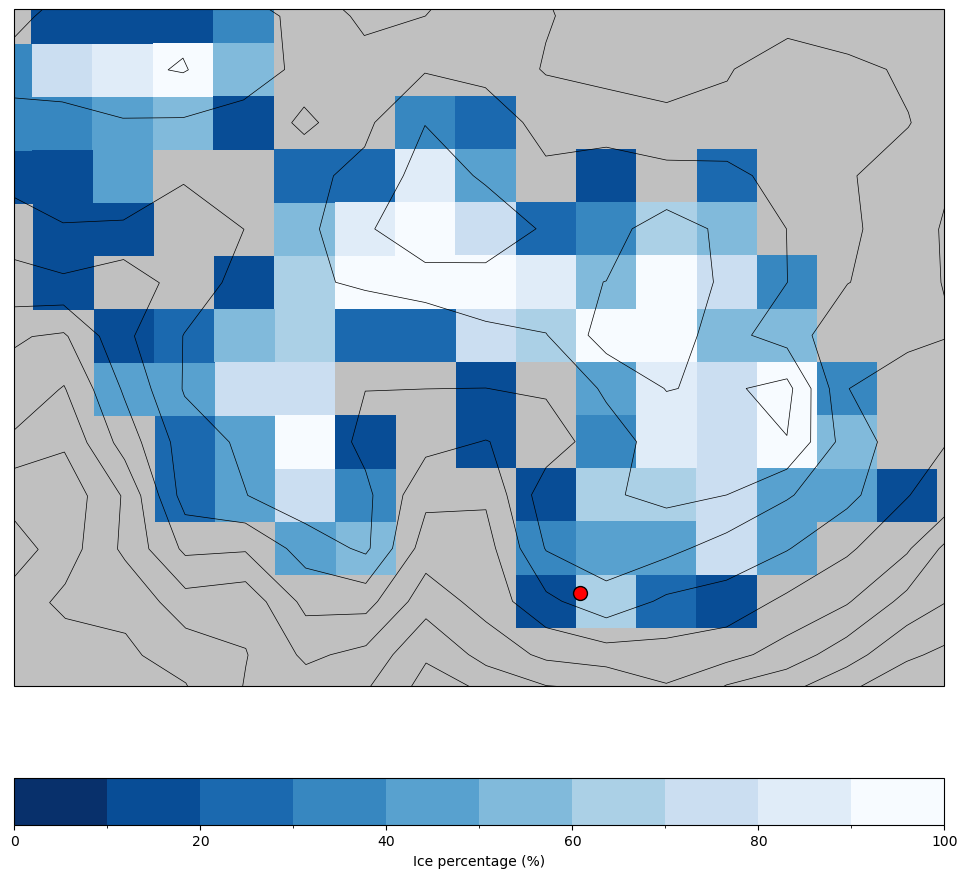

In [6]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

ax.set_facecolor('silver')
#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Percentage of ice ####
im = ax.pcolormesh(ds_lon, ds_lat, ICE_mask,
                   cmap=cmap, norm=norm_blue, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.set_extent([86.2, 87.3, 27.6, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

plt.colorbar(im, orientation="horizontal", pad=0.1, label="Ice percentage (%)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

# Affichage du Sector 0 pour la variable SMB (janvier)

In [7]:
sector = 1

In [8]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 
 
file_sector = variable+'_daysum_MARv3.14_ER5_spin2_GRq_2024.nc'

ds_sector = xr.open_dataset(DataPath + file_sector)

sector_SMB = ds_sector.SMB.isel(TIME=0, SECTOR=sector).load()   # SECTOR de MAR ".sel" selectionne la vraie valeur de sector (1 ou 2). ".isel" selectionne l'indice (0 ou 1)
sector_SMB = sector_SMB.isel(Y=slice(k, -k), X=slice(k, -k))

# Permet d'afficher l'echelles de valeur en couleur avec séparateurs distincts mais dépendant des valeurs 
data = sector_SMB.values  
n_classes = 10
cmap = plt.get_cmap("Reds", n_classes)
norm_red = mcolors.BoundaryNorm(np.linspace(data.min(), data.max(), n_classes+1), cmap.N)

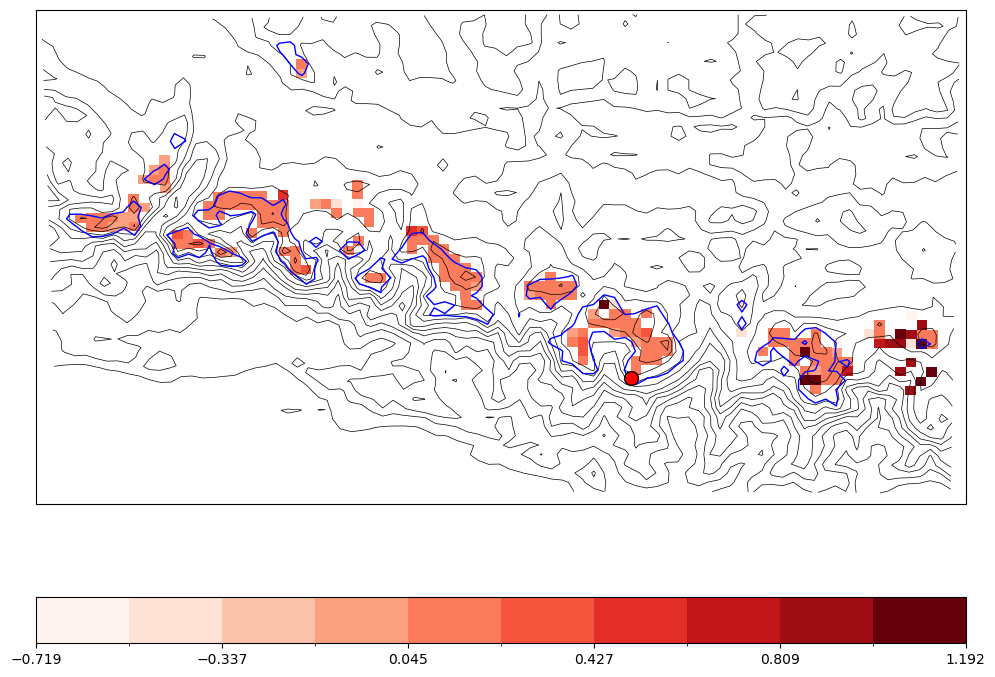

In [9]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

# Le mask indique que si le SMB est = 0 alors on ne prend pas en compte ces valeurs dans l'affichage 
#(permet d'avoir en blanc les cases où on a pas de surface avec de la glace)
sector_mask = np.ma.masked_where(sector_SMB ==0, sector_SMB) 

#### SECTOR ####
im = ax.pcolormesh(ds_lon, ds_lat, sector_mask,
              cmap=cmap, norm=norm_red,
              transform=ccrs.PlateCarree(),
              shading="auto")

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

plt.colorbar(im, orientation="horizontal", pad=0.1)

plt.show()

# Carte de la région du Mera 

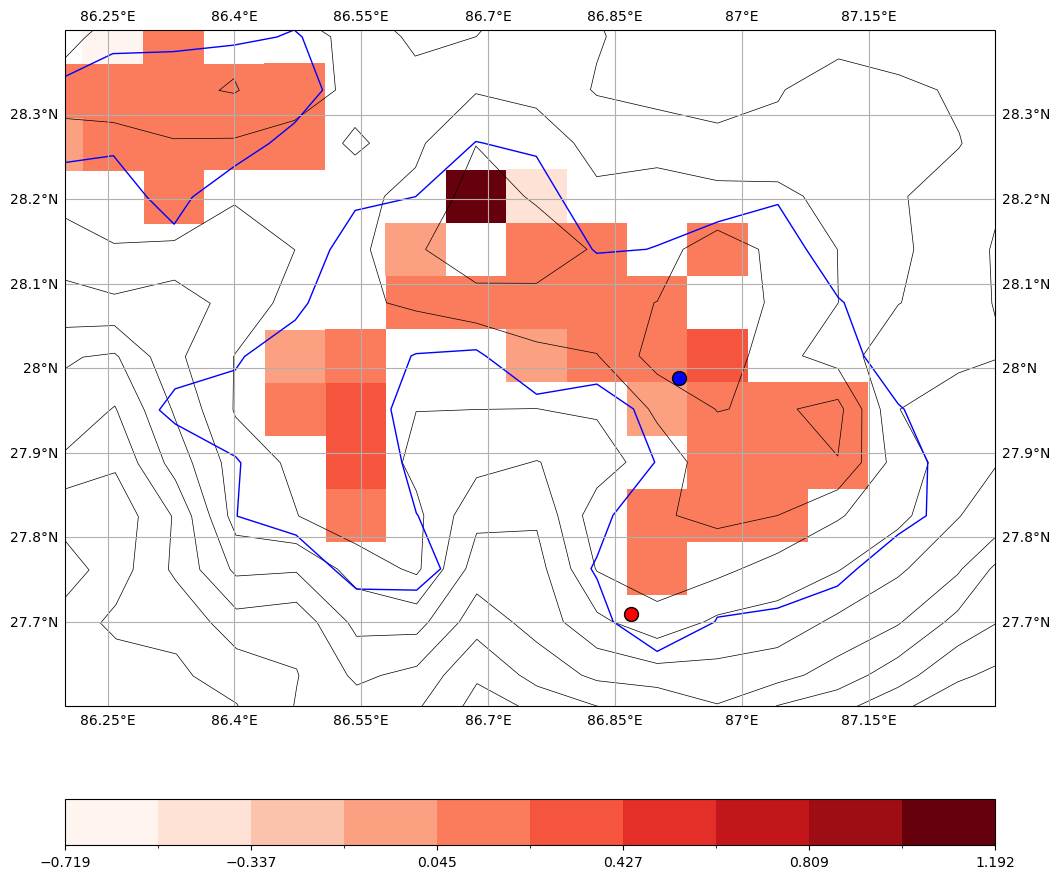

In [10]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

sector_mask = np.ma.masked_where(sector_SMB ==0, sector_SMB)

#### SECTOR ####
im = ax.pcolormesh(ds_lon, ds_lat, sector_mask,
              cmap=cmap,
              norm=norm_red,
              transform=ccrs.PlateCarree(),
              shading="auto")

plt.colorbar(im, orientation="horizontal", pad=0.1)

#ax.contour(ds_lon, ds_lat, sector_mask, levels=[0.5], colors="red", linewidths=2, transform=ccrs.PlateCarree())


#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Everest coord ####
ax.plot(everest_lon, everest_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='b',
        transform=ccrs.PlateCarree())

ax.set_extent([86.2, 87.3, 27.6, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.2, 87.4, 27.3, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.show()